In [3]:
from google.colab import files
import pandas as pd

# Upload file
uploaded = files.upload()

# Get uploaded file name automatically
filename = list(uploaded.keys())[0]

print("Uploaded file:", filename)

# Read CSV
df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

# Show first 5 rows
df.head()

Saving retail-orders-raw (3).csv to retail-orders-raw (3).csv
Uploaded file: retail-orders-raw (3).csv
Dataset loaded successfully!
Shape: (12, 9)


,order_id,order_date,customer_segment,city,category,quantity,unit_price,discount_pct,payment_status
0,RT-1001,2026-01-03,Student,Chennai,Learning Kit,2,799,10.0,Paid
1,RT-1002,03/01/2026,Fresher,Bengaluru,Course Access,1,1499,0.0,paid
2,RT-1003,2026-01-05,student,Chennai,Course Access,1,1499,NaN,Pending
3,RT-1004,2026-01-07,Professional,Hyderabad,Learning Kit,3,799,5.0,Paid
4,RT-1004,2026-01-07,Professional,Hyderabad,Learning Kit,3,799,5.0,Paid


In [4]:
# ============================================================
# STEP 2: DESCRIPTIVE STATISTICS
# ============================================================

import numpy as np
import pandas as pd

# Numerical columns மட்டும் select செய்யும்
numeric_cols = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(list(numeric_cols))

# Descriptive statistics
statistics = df[numeric_cols].describe().T

# Add median
statistics["median"] = df[numeric_cols].median()

# Display important statistics
statistics = statistics[
    [
        "count",
        "mean",
        "median",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
]

print("\nDescriptive Statistics:")
display(statistics.round(2))

Numerical Columns:
['unit_price', 'discount_pct']

Descriptive Statistics:


,count,mean,median,std,min,25%,50%,75%,max
unit_price,12.0,1082.33,999.0,318.61,799.0,799.0,999.0,1499.0,1499.0
discount_pct,11.0,13.64,5.0,30.75,0.0,0.0,5.0,10.0,105.0


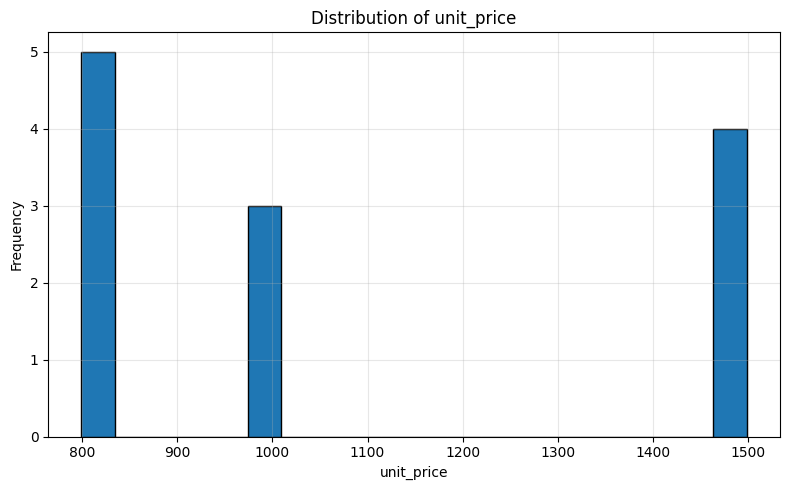

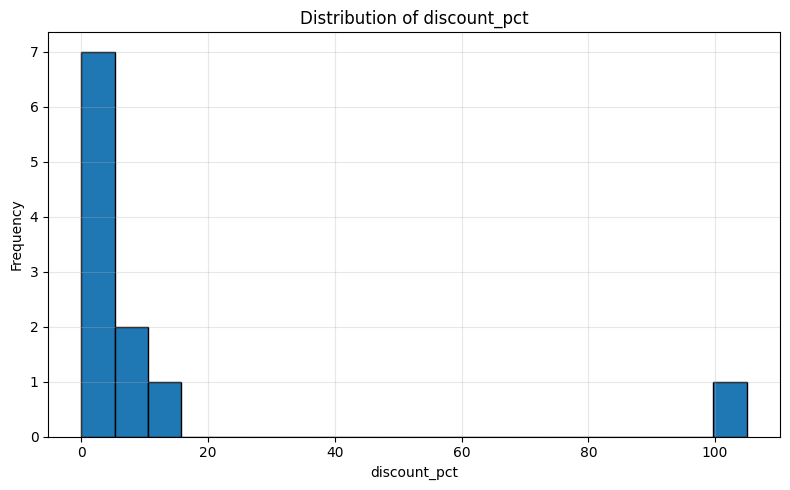

In [5]:
# ============================================================
# STEP 3: HISTOGRAM DISTRIBUTIONS
# ============================================================

import matplotlib.pyplot as plt

for col in numeric_cols:

    plt.figure(figsize=(8, 5))

    plt.hist(
        df[col].dropna(),
        bins=20,
        edgecolor="black"
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

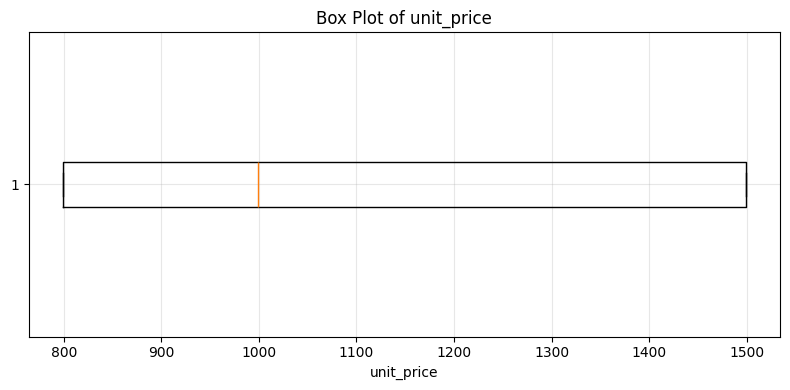

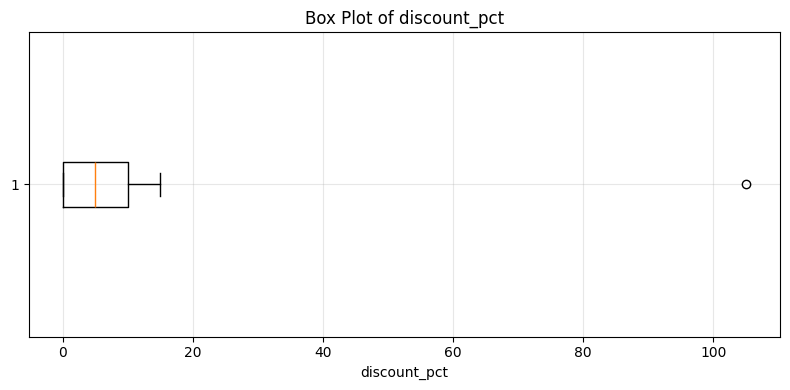

In [6]:
# ============================================================
# STEP 4: BOX PLOT - OUTLIER DETECTION
# ============================================================

import matplotlib.pyplot as plt

for col in numeric_cols:

    plt.figure(figsize=(8, 4))

    plt.boxplot(
        df[col].dropna(),
        vert=False
    )

    plt.title(f"Box Plot of {col}")
    plt.xlabel(col)
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [7]:
# ============================================================
# OUTLIER COUNT USING IQR
# ============================================================

outlier_summary = []

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_limit) |
        (df[col] > upper_limit)
    ]

    outlier_summary.append({
        "Column": col,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Outlier Count": len(outliers)
    })

outlier_table = pd.DataFrame(outlier_summary)

display(outlier_table)

,Column,Q1,Q3,IQR,Outlier Count
0,unit_price,799.0,1499.0,700.0,0
1,discount_pct,0.0,10.0,10.0,1


In [8]:
# ============================================================
# STEP 5: CORRELATION MATRIX
# ============================================================

# Calculate correlation
correlation_matrix = df[numeric_cols].corr()

print("Correlation Matrix:")
display(correlation_matrix.round(3))

Correlation Matrix:


,unit_price,discount_pct
unit_price,1.000,-0.057
discount_pct,-0.057,1.000


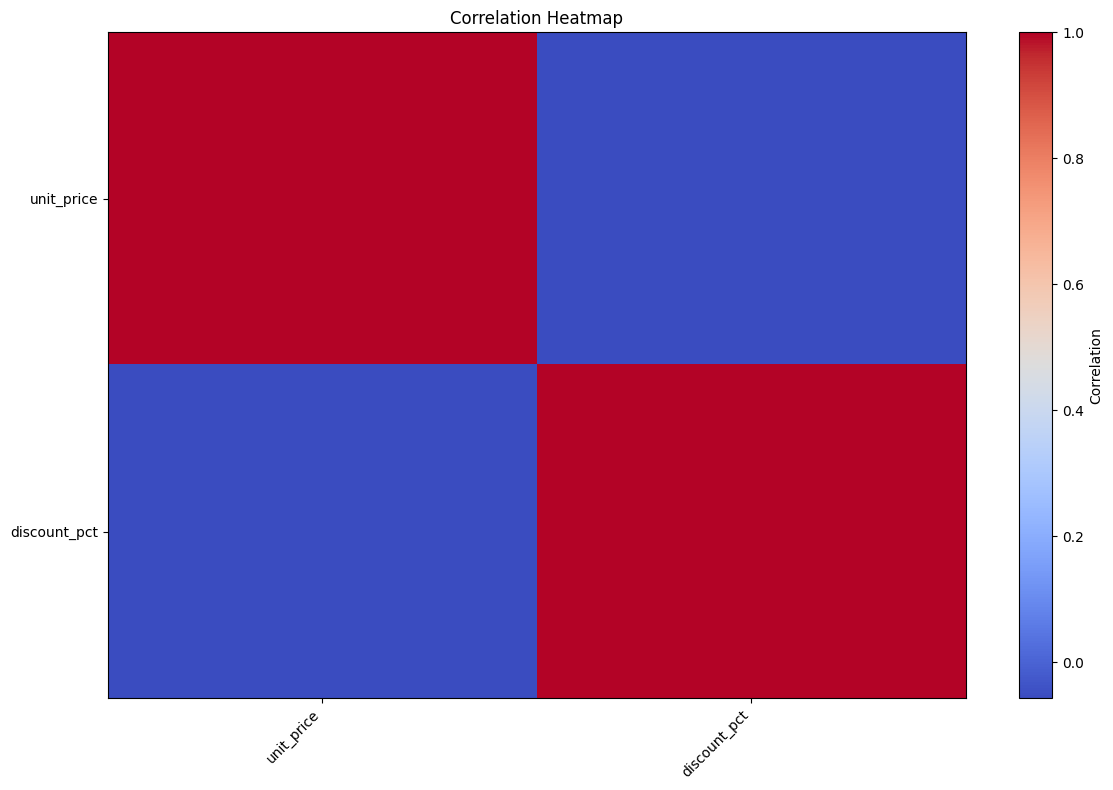

In [9]:
# ============================================================
# CORRELATION HEATMAP
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

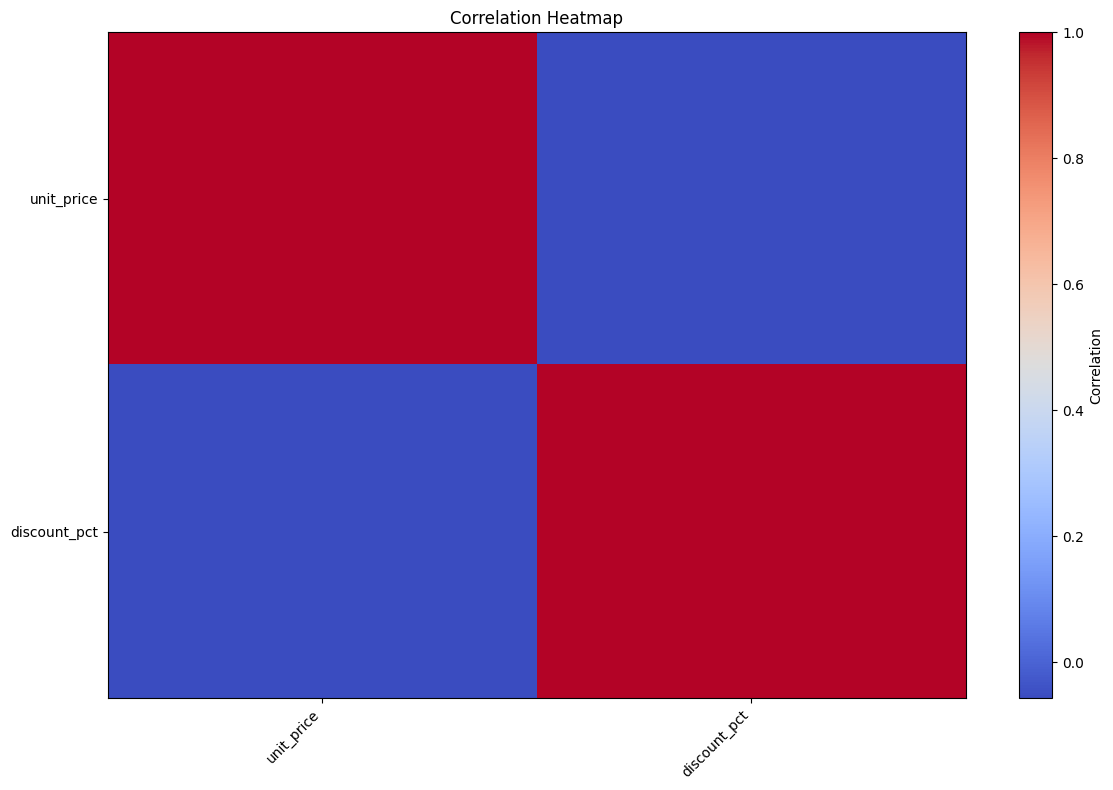

In [10]:
# ============================================================
# CORRELATION HEATMAP
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# STEP 6: STRONGEST CORRELATIONS
# ============================================================

corr_pairs = []

columns = correlation_matrix.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):

        col1 = columns[i]
        col2 = columns[j]

        value = correlation_matrix.loc[col1, col2]

        corr_pairs.append(
            (col1, col2, value)
        )

# Sort by absolute correlation
corr_pairs = sorted(
    corr_pairs,
    key=lambda x: abs(x[2]),
    reverse=True
)

print("Top 10 Strongest Correlations:\n")

for col1, col2, value in corr_pairs[:10]:
    print(
        f"{col1} <-> {col2} : {value:.3f}"
    )

Top 10 Strongest Correlations:

unit_price <-> discount_pct : -0.057


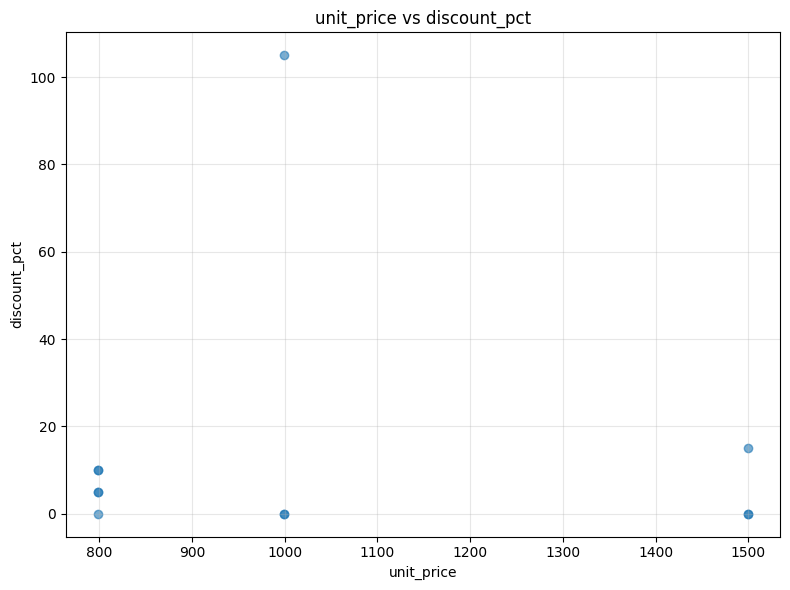

X-axis: unit_price
Y-axis: discount_pct


In [12]:
# ============================================================
# STEP 7: MULTIVARIATE VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

if len(numeric_cols) >= 2:

    x = numeric_cols[0]
    y = numeric_cols[1]

    plt.figure(figsize=(8, 6))

    plt.scatter(
        df[x],
        df[y],
        alpha=0.6
    )

    plt.title(f"{x} vs {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"X-axis: {x}")
    print(f"Y-axis: {y}")

In [13]:
# ============================================================
# STEP 8: BUSINESS HYPOTHESIS TESTING
# ============================================================

from scipy.stats import pearsonr
import pandas as pd

print("=" * 60)
print("BUSINESS HYPOTHESIS TESTING")
print("=" * 60)

# Create 3 variable pairs automatically
hypothesis_pairs = []

for i in range(min(3, len(numeric_cols) - 1)):

    x = numeric_cols[i]
    y = numeric_cols[i + 1]

    hypothesis_pairs.append((x, y))


results = []

for x, y in hypothesis_pairs:

    # Remove missing values
    temp = df[[x, y]].dropna()

    if len(temp) > 2:

        # Pearson correlation test
        correlation, p_value = pearsonr(
            temp[x],
            temp[y]
        )

        # Hypothesis decision
        if p_value < 0.05:
            decision = "Reject H0"
            conclusion = "Significant relationship"
        else:
            decision = "Fail to reject H0"
            conclusion = "No significant relationship"

        # Store result
        results.append({
            "Variable 1": x,
            "Variable 2": y,
            "Correlation": round(correlation, 4),
            "P-value": round(p_value, 4),
            "Decision": decision,
            "Conclusion": conclusion
        })

        # Print result
        print("\n----------------------------------------")
        print(f"Hypothesis: {x} vs {y}")
        print("----------------------------------------")

        print("Correlation :", round(correlation, 4))
        print("P-value     :", round(p_value, 4))
        print("Decision    :", decision)
        print("Conclusion  :", conclusion)


# ============================================================
# HYPOTHESIS RESULTS TABLE
# ============================================================

print("\n" + "=" * 60)
print("HYPOTHESIS TEST RESULTS")
print("=" * 60)

hypothesis_results = pd.DataFrame(results)

display(hypothesis_results)

BUSINESS HYPOTHESIS TESTING

----------------------------------------
Hypothesis: unit_price vs discount_pct
----------------------------------------
Correlation : -0.0568
P-value     : 0.8683
Decision    : Fail to reject H0
Conclusion  : No significant relationship

HYPOTHESIS TEST RESULTS


,Variable 1,Variable 2,Correlation,P-value,Decision,Conclusion
0,unit_price,discount_pct,-0.0568,0.8683,Fail to reject H0,No significant relationship


In [14]:
# ============================================================
# STEP 9: TOP 5 CRITICAL FINDINGS
# ============================================================

print("=" * 60)
print("TOP 5 CRITICAL FINDINGS")
print("=" * 60)

# Finding 1: Dataset size
print(
    f"\n1. Dataset contains {df.shape[0]} rows "
    f"and {df.shape[1]} columns."
)

# Finding 2: Missing values
total_missing = df.isnull().sum().sum()

print(
    f"\n2. Total missing values in the dataset: "
    f"{total_missing}."
)

# Finding 3: Duplicate records
duplicates = df.duplicated().sum()

print(
    f"\n3. Total duplicate records: "
    f"{duplicates}."
)

# Finding 4: Strongest correlation
if len(corr_pairs) > 0:

    strongest = corr_pairs[0]

    print(
        f"\n4. Strongest relationship is between "
        f"{strongest[0]} and {strongest[1]} "
        f"with correlation {strongest[2]:.3f}."
    )

# Finding 5: Highest outliers
if len(outlier_table) > 0:

    highest_outlier = outlier_table.loc[
        outlier_table["Outlier Count"].idxmax()
    ]

    print(
        f"\n5. {highest_outlier['Column']} has the highest "
        f"number of potential outliers: "
        f"{highest_outlier['Outlier Count']}."
    )


# ============================================================
# FINAL EDA SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("EDA COMPLETED SUCCESSFULLY")
print("=" * 60)

print("""
The Exploratory Data Analysis examined the retail dataset
using descriptive statistics, histograms, box plots,
correlation analysis, multivariate visualization,
outlier detection, and business hypothesis testing.

The analysis provides useful statistical insights into
the dataset and helps identify relationships, unusual
observations, and important business patterns.
""")

TOP 5 CRITICAL FINDINGS

1. Dataset contains 12 rows and 9 columns.

2. Total missing values in the dataset: 3.

3. Total duplicate records: 1.

4. Strongest relationship is between unit_price and discount_pct with correlation -0.057.

5. discount_pct has the highest number of potential outliers: 1.

EDA COMPLETED SUCCESSFULLY

The Exploratory Data Analysis examined the retail dataset
using descriptive statistics, histograms, box plots,
correlation analysis, multivariate visualization,
outlier detection, and business hypothesis testing.

The analysis provides useful statistical insights into
the dataset and helps identify relationships, unusual
observations, and important business patterns.

